In [1]:
__nbid__ = '0084'
__author__ = 'Brian Merino <brian.merino@noirlab.edu>, Vinicius Placco <vinicius.placco@noirlab.edu>'
__version__ = '20260615' # yyyymmdd; version datestamp of this notebook
__keywords__ = ['gnirs','Gemini','cross-dispersed','DRAGONS', 'supernova']

# Gemini GNIRS XD Supernova type II reduction using DRAGONS Python API
***
## Public archival data from GN-2016B-Q-57 (Type II Supernova 2016ija/DLT16am)

#### adapted from https://gnirsxd-drtutorial.readthedocs.io/en/stable/ex1_gnirsxd_SXD32mm_api.html
***

## Table of contents
* [Goals](#goals)
* [Summary](#summary)
* [Imports and setup](#imports)
* [Prepare the working directory](#Prepare)
* [About the dataset](#About)
* [Account Authentication and Data Access](#Downloading_Data)
* [Set up the DRAGONS logger](#DRAGONS_logger)
* [Create File Lists](#File_Lists)
* [Create Bad Pixel Mask](#BPM)
* [Create Master Flat Field](#Master_Flat)
* [Processed pinholes](#pinholes)
* [Processed arc](#Arc)
* [Telluric standard](#Telluric) 
* [Reduce Science Images](#Reduce_Science)
* [Display the 1D extracted spectrum](#Display_extracted)
* [Display the telluric corrected spectrum](#Display_telluricCorrected)
* [Display the final spectrum](#Display_final)
* [Combine orders](#Combine_orders)
* [Display the combined orders](#Display_Combine_orders)
* [Clean-up (optional)](#Clean-up)
 
<a class="anchor" id="goals"></a>
# Goals
Showcase how to reduce GNIRS XD with Short-Blue + 32 l/mm grating data using the Gemini DRAGONS package on the Data Lab science platform using a custom DRAGONS kernel `"DRAGONS-4.2.1 (DL,Py3.12)"`. The steps include downloading data from the Gemini archive, setting up a DRAGONS calibration service, processing flats, darks, a bad pixel mask, and science frames, and creating a final reduced spectrum. 

<a class="anchor" id="summary"></a>
# Summary
DRAGONS is a Python-based astronomical data reduction platform written by the Gemini Science User Support Department. It can currently be used to reduce imaging data from Gemini instruments GMOS, NIRI, Flamingos 2, GSAOI, and GNIRS, as well as spectroscopic data taken with Flamingos 2, GNIRS, GHOST, and GMOS in longslit mode and GNIRS data taken in cross-dispersion mode. Linked <a href="https://dragons.readthedocs.io/en/stable/">here</a> is a general list of guides, manuals, and tutorials about the use of DRAGONS.

The DRAGONS kernel has been made available in the Data Lab environment, allowing users to access the routines without being dependent on installing the software on their local machines. 

In this notebook, we present an example of a DRAGONS Jupyter notebook that works in the Data Lab environment to reduce example GNIRS XD with Short-Blue + 32 l/mm grating data fully. This notebook will not present all of the details of the many options available to adjust or optimize the DRAGONS GNIRS XD data reduction process; rather, it will just show one example of a standard reduction of a GNIRS XD dataset. 

The data used in this notebook is GNIRS cross-dispersed observation data of a type II supernova 54 days after explosion. This observation program used the 32 l/mm grating, the short-blue camera, and the 0.675 arcsec slit. The data is from the Gemini North program "<a href="https://archive.gemini.edu/programinfo/GN-2016B-Q-57">Constraining Type Ia Supernova Physics with Near-Infrared Spectroscopy (North)</a>", PI: David Sand, program ID GN-2016B-Q-57.

<a class="anchor" id="disclaimer"></a>
# Disclaimer & attribution

Disclaimers
-----------
Note that using the Astro Data Lab constitutes your agreement with our minimal [Disclaimers](https://datalab.noirlab.edu/disclaimers.php).

Acknowledgments
---------------
If you use **Astro Data Lab** in your published research, please include the text in your paper's Acknowledgments section:

_This research uses services or data provided by the Astro Data Lab, which is part of the Community Science and Data Center (CSDC) Program of NSF NOIRLab. NOIRLab is operated by the Association of Universities for Research in Astronomy (AURA), Inc. under a cooperative agreement with the U.S. National Science Foundation._

If you use **SPARCL jointly with the Astro Data Lab platform** (via JupyterLab, command-line, or web interface) in your published research, please include this text below in your paper's Acknowledgments section:

_This research uses services or data provided by the SPectra Analysis and Retrievable Catalog Lab (SPARCL) and the Astro Data Lab, which are both part of the Community Science and Data Center (CSDC) Program of NSF NOIRLab. NOIRLab is operated by the Association of Universities for Research in Astronomy (AURA), Inc. under a cooperative agreement with the U.S. National Science Foundation._

In either case **please cite the following papers**:

* Data Lab concept paper: Fitzpatrick et al., "The NOAO Data Laboratory: a conceptual overview", SPIE, 9149, 2014, https://doi.org/10.1117/12.2057445

* Astro Data Lab overview: Nikutta et al., "Data Lab - A Community Science Platform", Astronomy and Computing, 33, 2020, https://doi.org/10.1016/j.ascom.2020.100411

If you are referring to the Data Lab JupyterLab / Jupyter Notebooks, cite:

* Juneau et al., "Jupyter-Enabled Astrophysical Analysis Using Data-Proximate Computing Platforms", CiSE, 23, 15, 2021, https://doi.org/10.1109/MCSE.2021.3057097

If publishing in a AAS journal, also add the keyword: `\facility{Astro Data Lab}`

And if you are using SPARCL, please also add `\software{SPARCL}` and cite:

* Juneau et al., "SPARCL: SPectra Analysis and Retrievable Catalog Lab", Conference Proceedings for ADASS XXXIII, 2024
https://doi.org/10.48550/arXiv.2401.05576

The NOIRLab Library maintains [lists of proper acknowledgments](https://noirlab.edu/science/about/scientific-acknowledgments) to use when publishing papers using the Lab's facilities, data, or services.

For this notebook specifically, please acknowledge:
* DRAGONS publication: Labrie et al., <a href="https://ui.adsabs.harvard.edu/abs/2019ASPC..523..321L/abstract">"DRAGONS - Data Reduction for Astronomy from Gemini Observatory North and South"</a>, ASPC, 523, 321L 

* <a href="https://zenodo.org/record/7776065#.ZDg5qOzMLUI">DRAGONS open source software publication</a>

<a class="anchor" id="imports"></a>
# Importing Python libraries

In [2]:
import warnings
import glob
import os
import shutil
import requests
import astrodata

from astropy.io import fits
from astropy.wcs import WCS
from astropy.utils.exceptions import AstropyWarning
from astroquery.simbad import Simbad

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import gemini_instruments
from gempy.utils import logutils
from gempy.adlibrary import dataselect
from gempy.adlibrary import plotting

from recipe_system import cal_service
from recipe_system.reduction.coreReduce import Reduce

from pathlib import Path
from urllib.parse import urlparse

warnings.simplefilter('ignore', category=AstropyWarning)
warnings.filterwarnings("ignore")

<a class="anchor" id="Prepare"></a>
# Prepare the working directory

If you have any intermediate files that were created from running this code in the past, you will need to remove them from your working directory. The cell below defines a clean-up function that will remove all the fits files from your working directory. This function will be called again at the end of the tutorial, leaving you with only the final product. By default, this function will delete all files in the working directory. If there are files that have been previously reduced that you would like to keep, set `save_reduced=1` when calling the function.

In [3]:
def clean_up(save_reduced=0):
    """Remove all the intermediate files in the working directory. 
    
    Parameters
    ----------
    save_reduced : int
        Set save_reduced to 0 to remove all of the files in the working
        directory including the calibration folder. 
        Set save_reduced to 1 to save the intermediate files that were
        created during the reduction.
    
    Examples
    --------
    clean_up(save_reduced=0)
    """    
    #Does the calibrations directory already exist?
    caldb_Exist = os.path.exists('./calibrations') 
    
    if caldb_Exist:
        shutil.rmtree('./calibrations', ignore_errors=True)

    #Remove existing log and list files.
    work_dir_path = os.getcwd()
    work_dir = os.listdir(work_dir_path)

    for item in work_dir:
        if item.endswith(".log") or item.endswith(".list"):
            os.remove(os.path.join(work_dir_path, item))
    
    #Next, we will remove all the existing fits files, except for the previously reduced files, depending on what you set save_reduced to.
    if save_reduced:
        all_files_0 = glob.glob('*.fits')
        save = dataselect.select_data(all_files_0, [], ['PROCESSED'])
        
        for s in save:
            os.remove(os.path.join(work_dir_path,s))

    else:
        all_files_0 = glob.glob('*.fits')
        for a in all_files_0:
            os.remove(os.path.join(work_dir_path,a))

In [4]:
clean_up(save_reduced=0)

<a class="anchor" id="About"></a>
# About the dataset
This data comes from a GNIRS XD program that observed a type II supernova 54 days after explosion. The flats, pinholes, arcs, and telluric standards were taken in the same configuration as the science. 


| Observation Type | File name(s) |
| :--- | :--- |
| Science | N20170113S0146-165 |
| Science flats | N20170113S0168-183 |
| Pinholes | N20170113S0569-573 |
| Science arcs | N20170113S0166-167 |
| Telluric | N20170113S0123-138 |
| BPM | bpm_20121101_gnirs_gnirsn_11_full_1amp.fits |

<a class="anchor" id="Downloading_Data"></a>
# Downloading the data

Download GNIRS cross-dispersed data from the Gemini archive to the current working directory. This step only needs to be executed once.

If you run this notebook for the first time and need to download the dataset, set the variable "download=True". The notebook will not redownload the dataset if it is set to False. This will become particularly useful if you run the notebooks more than once. 

In [5]:
%%bash 

# create file that lists FITS files to be downloaded
echo "\
http://archive.gemini.edu/file/N20170113S0146.fits
http://archive.gemini.edu/file/N20170113S0147.fits
http://archive.gemini.edu/file/N20170113S0148.fits
http://archive.gemini.edu/file/N20170113S0149.fits
http://archive.gemini.edu/file/N20170113S0150.fits
http://archive.gemini.edu/file/N20170113S0151.fits
http://archive.gemini.edu/file/N20170113S0152.fits
http://archive.gemini.edu/file/N20170113S0153.fits
http://archive.gemini.edu/file/N20170113S0154.fits
http://archive.gemini.edu/file/N20170113S0155.fits
http://archive.gemini.edu/file/N20170113S0156.fits
http://archive.gemini.edu/file/N20170113S0157.fits
http://archive.gemini.edu/file/N20170113S0158.fits
http://archive.gemini.edu/file/N20170113S0159.fits
http://archive.gemini.edu/file/N20170113S0160.fits
http://archive.gemini.edu/file/N20170113S0161.fits
http://archive.gemini.edu/file/N20170113S0162.fits
http://archive.gemini.edu/file/N20170113S0163.fits
http://archive.gemini.edu/file/N20170113S0164.fits
http://archive.gemini.edu/file/N20170113S0165.fits
http://archive.gemini.edu/file/N20170113S0168.fits
http://archive.gemini.edu/file/N20170113S0169.fits
http://archive.gemini.edu/file/N20170113S0170.fits
http://archive.gemini.edu/file/N20170113S0171.fits
http://archive.gemini.edu/file/N20170113S0172.fits
http://archive.gemini.edu/file/N20170113S0173.fits
http://archive.gemini.edu/file/N20170113S0174.fits
http://archive.gemini.edu/file/N20170113S0175.fits
http://archive.gemini.edu/file/N20170113S0176.fits
http://archive.gemini.edu/file/N20170113S0177.fits
http://archive.gemini.edu/file/N20170113S0178.fits
http://archive.gemini.edu/file/N20170113S0179.fits
http://archive.gemini.edu/file/N20170113S0180.fits
http://archive.gemini.edu/file/N20170113S0181.fits
http://archive.gemini.edu/file/N20170113S0182.fits
http://archive.gemini.edu/file/N20170113S0183.fits
http://archive.gemini.edu/file/N20170113S0569.fits
http://archive.gemini.edu/file/N20170113S0570.fits
http://archive.gemini.edu/file/N20170113S0571.fits
http://archive.gemini.edu/file/N20170113S0572.fits
http://archive.gemini.edu/file/N20170113S0573.fits
http://archive.gemini.edu/file/N20170113S0166.fits
http://archive.gemini.edu/file/N20170113S0167.fits
http://archive.gemini.edu/file/N20170113S0123.fits
http://archive.gemini.edu/file/N20170113S0124.fits
http://archive.gemini.edu/file/N20170113S0125.fits
http://archive.gemini.edu/file/N20170113S0126.fits
http://archive.gemini.edu/file/N20170113S0127.fits
http://archive.gemini.edu/file/N20170113S0128.fits
http://archive.gemini.edu/file/N20170113S0129.fits
http://archive.gemini.edu/file/N20170113S0130.fits
http://archive.gemini.edu/file/N20170113S0131.fits
http://archive.gemini.edu/file/N20170113S0132.fits
http://archive.gemini.edu/file/N20170113S0133.fits
http://archive.gemini.edu/file/N20170113S0134.fits
http://archive.gemini.edu/file/N20170113S0135.fits
http://archive.gemini.edu/file/N20170113S0136.fits
http://archive.gemini.edu/file/N20170113S0137.fits
http://archive.gemini.edu/file/N20170113S0138.fits
http://archive.gemini.edu/file/bpm_20121101_gnirs_gnirsn_11_full_1amp.fits\
" > gnirs_xd.list

In [6]:
%%bash

download="True"

if [ $download == "True" ]; then
    wget --no-check-certificate -N -q -i gnirs_xd.list

else
    echo "Skipping download. To download the data set used in this notebook, set download=True."
fi

<a class="anchor" id="DRAGONS_logger"></a>
# Setting up the DRAGONS logger

DRAGONS comes with a local calibration manager that uses the same calibration association rules as the Gemini Observatory Archive. This allows reduce to make requests to a local light-weight database for matching processed calibrations when needed to reduce a dataset.

This tells the system where to put the calibration database. This database will keep track of the processed calibrations we will send to it.

In [7]:
logutils.config(file_name='gnirsxd_tutorial.log')
caldb = cal_service.set_local_database()
caldb.init("w")

**Create a list of all the FITS files in the directory**

In [8]:
all_files = glob.glob('*.fits')
all_files.sort()

<a class="anchor" id="File_Lists"></a>
# Create file lists

This data set contains science and calibration frames. For some programs, it could have different observed targets and exposure times depending on how you organize your raw data.

The DRAGONS data reduction pipeline does not organize the data for you. You have to do it. DRAGONS provides tools to help you with that.

The first step is to create lists that will be used in the data reduction process. For that, we use dataselect. Please refer to the [dataselect](https://dragons.readthedocs.io/projects/recipe-system-users-manual/en/stable/supptools/dataselect.html?highlight=dataselect) documentation for details regarding its usage.

## **A list for the flats**

The flats will need to be stacked together, so use the dataselect to identify the flat files that are compatible with each other.

In [9]:
flats = dataselect.select_data(all_files, ['FLAT'])

## **A list for the pinholes**

To create a list for the pinholes, we will have dataselect pick files with the observation class 'PINHOLE'.

In [10]:
pinholes = dataselect.select_data(all_files, ['PINHOLE'])

## **A list for the arcs**

The GNIRS longslit arcs were obtained at the end of the science observation. Often, two are taken. We will use both in this case and stack them later.

In [11]:
arcs = dataselect.select_data(all_files, ['ARC'])

## **A list for the tellurics**

Currently, DRAGONS does not have a way to differentiate telluric stars from the rest of the data. This is because GNIRS headers do not contain tags that specifically identify tellurics. In most instances, specifying the "observation_class" descriptor and rejecting files with the "CAL" tag are sufficient to distinguish between tellurics and science observations. 

In [12]:
tellurics = dataselect.select_data(
    all_files,
    [],
    ['CAL'],
    dataselect.expr_parser('observation_class=="partnerCal"')
)

## **A list for the science**

To create a list for the science observations, we will have dataselect pick files with the observation class 'science'. Note: In this example, all the science observations are of a single target. If the observation program had multiple targets, they would need to be split up into their own lists. 

In [13]:
scitarget = dataselect.select_data(
    all_files,
    [],
    ['CAL'],
    dataselect.expr_parser('observation_class=="science" and object=="DLT16am"')
)

<a class="anchor" id="BPM"></a>
# Create a bad pixel mask

Starting with DRAGONS v3.1, the static bad pixel masks (BPMs) are now handled as calibrations. They are downloadable from the archive instead of being packaged with the software. They are automatically associated like any other calibrations. This means that the user now must download the BPMs along with the other calibrations and add the BPMs to the local calibration manager.

In [14]:
for bpm in dataselect.select_data(all_files, ['BPM']):
    caldb.add_cal(bpm)

<a class="anchor" id="Master_Flat"></a>
# Create a master flat field

GNIRS XD flat fields are normally obtained at night along with the observation sequence to match the telescope and instrument flexure. The processed flat is constructed from two sets of stacked lamp-on flats, each illuminated differently to ensure that all orders in the reassembled flat are well illuminated. You do not have to worry about the details, as long as you pass the two sets of raw flats as input to the reduce command, the software will take care of the assembly.

The processed flat will also contain the illumination mask that identify the location of the illuminated areas in the array, ie, where the orders are located.

The master flat will have the name of the first flat file with the suffix _flat.fits.

All submitted files appear valid:
N20170113S0168.fits ... N20170113S0183.fits, 16 files submitted.


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
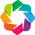

RECIPE: makeProcessedFlat
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0168_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0169_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0170_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0171_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0172_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0173_dataValidated.fits
         .
         PRIMITIVE

In [15]:
reduce_flats = Reduce()
reduce_flats.files.extend(flats)
reduce_flats.runr()

<a class="anchor" id="pinholes"></a>
# Processed Pinholes - Rectification

The pinholes are used to determine the rectification of the slanted and curved orders. The rectification model is calculated by tracing the dispersed image of each pinhole in each order.

The reduced pinhole file will have the name of the first pinhole file with the suffix _pinhole.fits.

In [16]:
reduce_pinholes = Reduce()
reduce_pinholes.files.extend(pinholes)
reduce_pinholes.runr()

All submitted files appear valid:
N20170113S0569.fits ... N20170113S0573.fits, 5 files submitted.
RECIPE: makeProcessedPinhole
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0569_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0570_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0571_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0572_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0573_dataValidated.fits
         .
      .
      PRIMITIVE: standardizeHeaders
 

<a class="anchor" id="Arc"></a>
# Processed arc - wavelength solution

Our configuration in this example is cross-dispersed with the short-blue camera and the 32 l/mm grating. This configuration generally has a sufficient number of lines available in all orders. For more information about wavelength calibration, see the [Wavelength Calibration Guide for GNIRS XD](https://gnirsxd-drtutorial.readthedocs.io/en/v4.1.0/gnirsxd_wavecal_guide.html#gnirsxd-wavecal-guide). The illumination mask will be obtained from the processed flat. The processed pinhole will provide the distortion correction.

The processed arc file will be named after the first pinhole file, with the suffix _arc.fits.

All submitted files appear valid:
N20170113S0166.fits ... N20170113S0167.fits, 2 files submitted.
RECIPE: makeProcessedArc
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0166_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0167_dataValidated.fits
         .
      .
      PRIMITIVE: standardizeHeaders
      -----------------------------
         PRIMITIVE: standardizeObservatoryHeaders
         ----------------------------------------
         Updating keywords that are common to all Gemini data
         .
         PRIMITIVE: standardizeInstrumentHeaders
         ---------------------------------------
         Updating keywords that are specific to GNIRS
         Updating keywords t

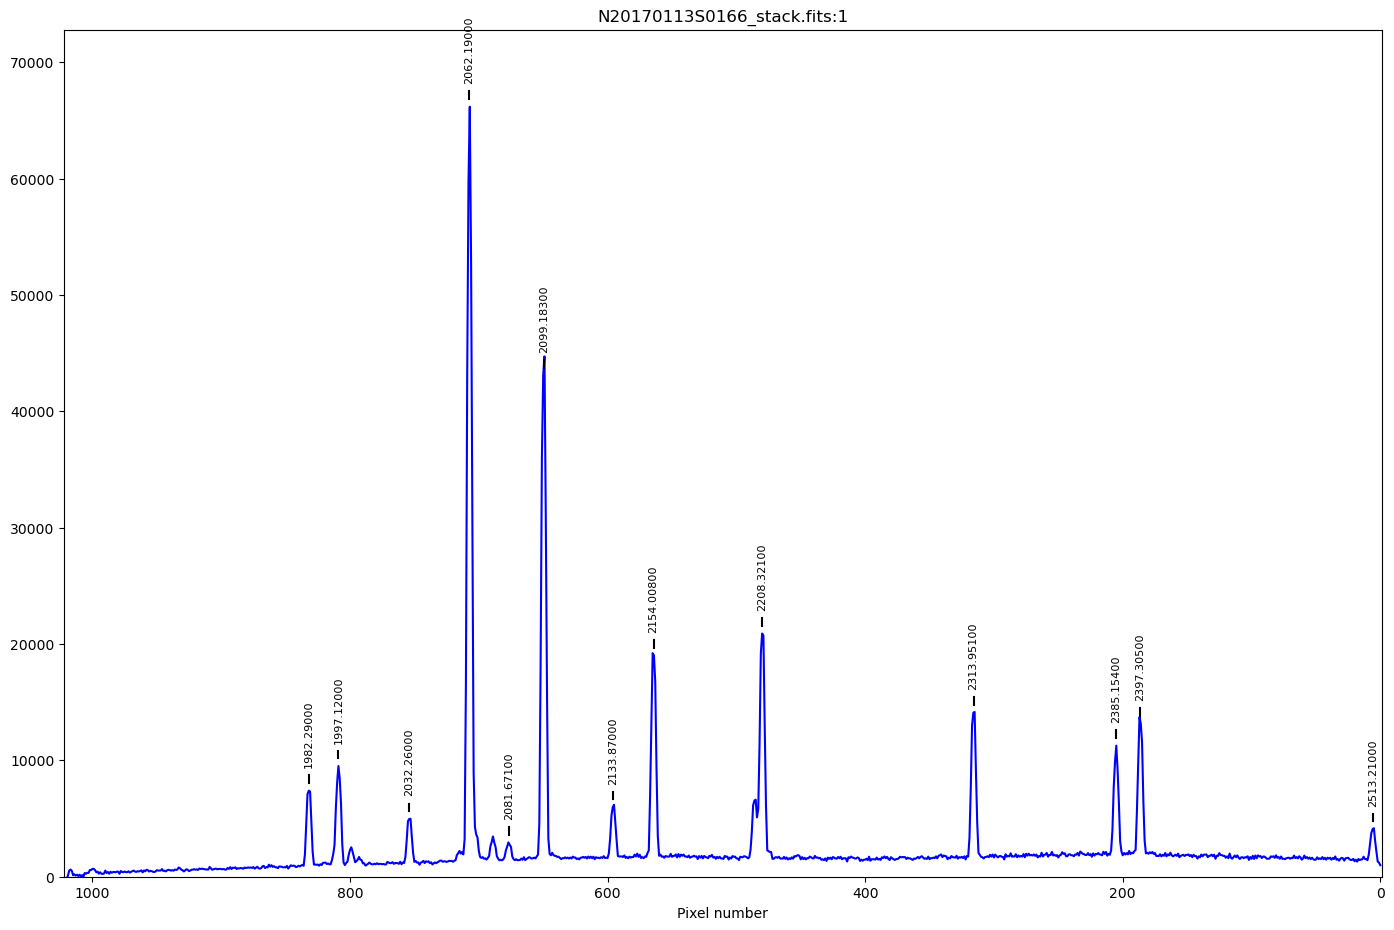

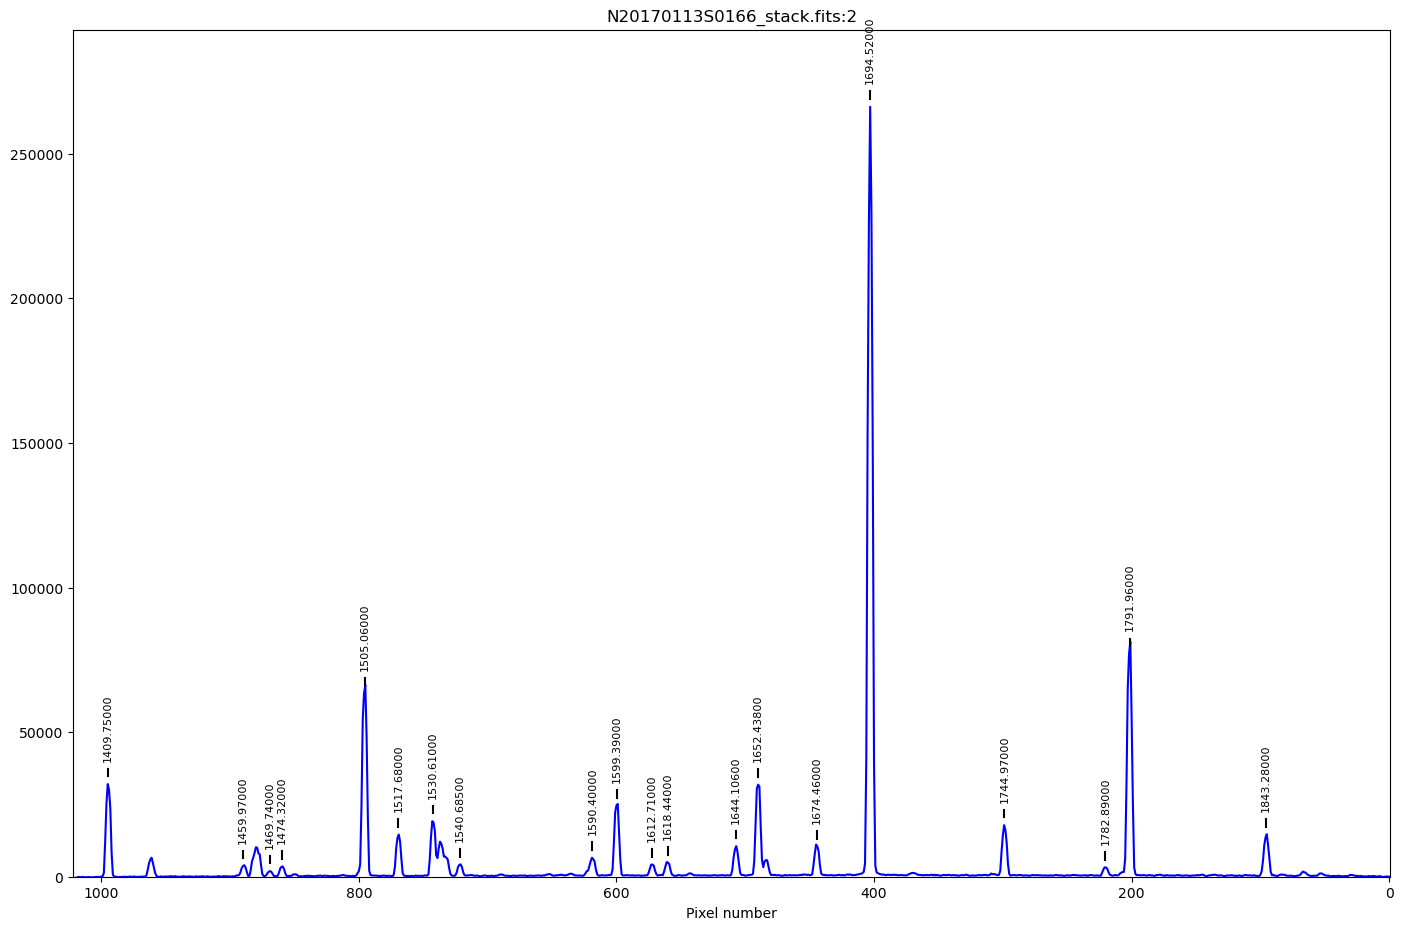

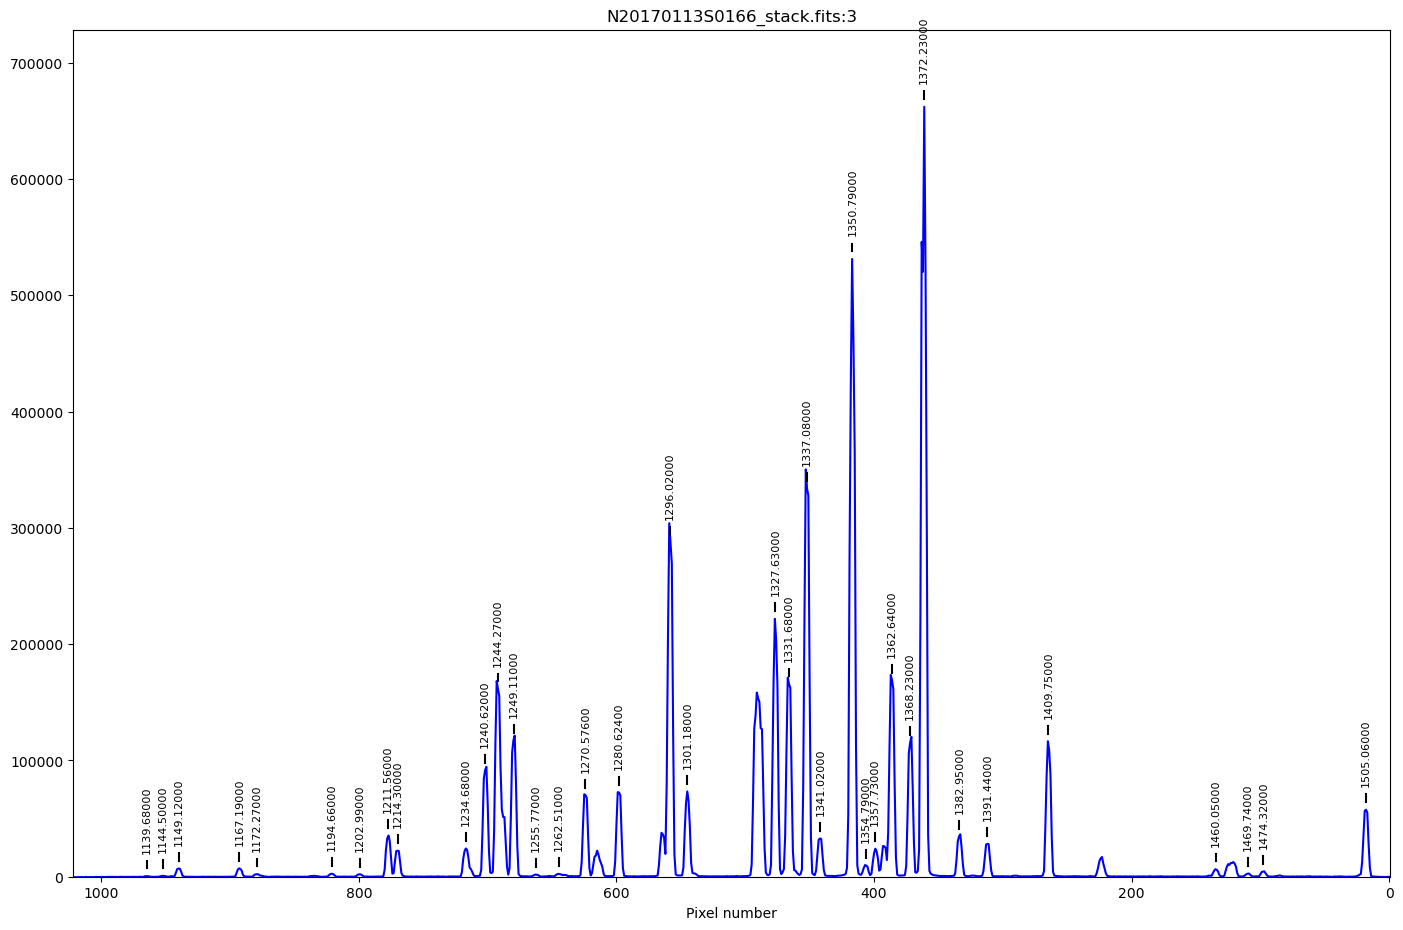

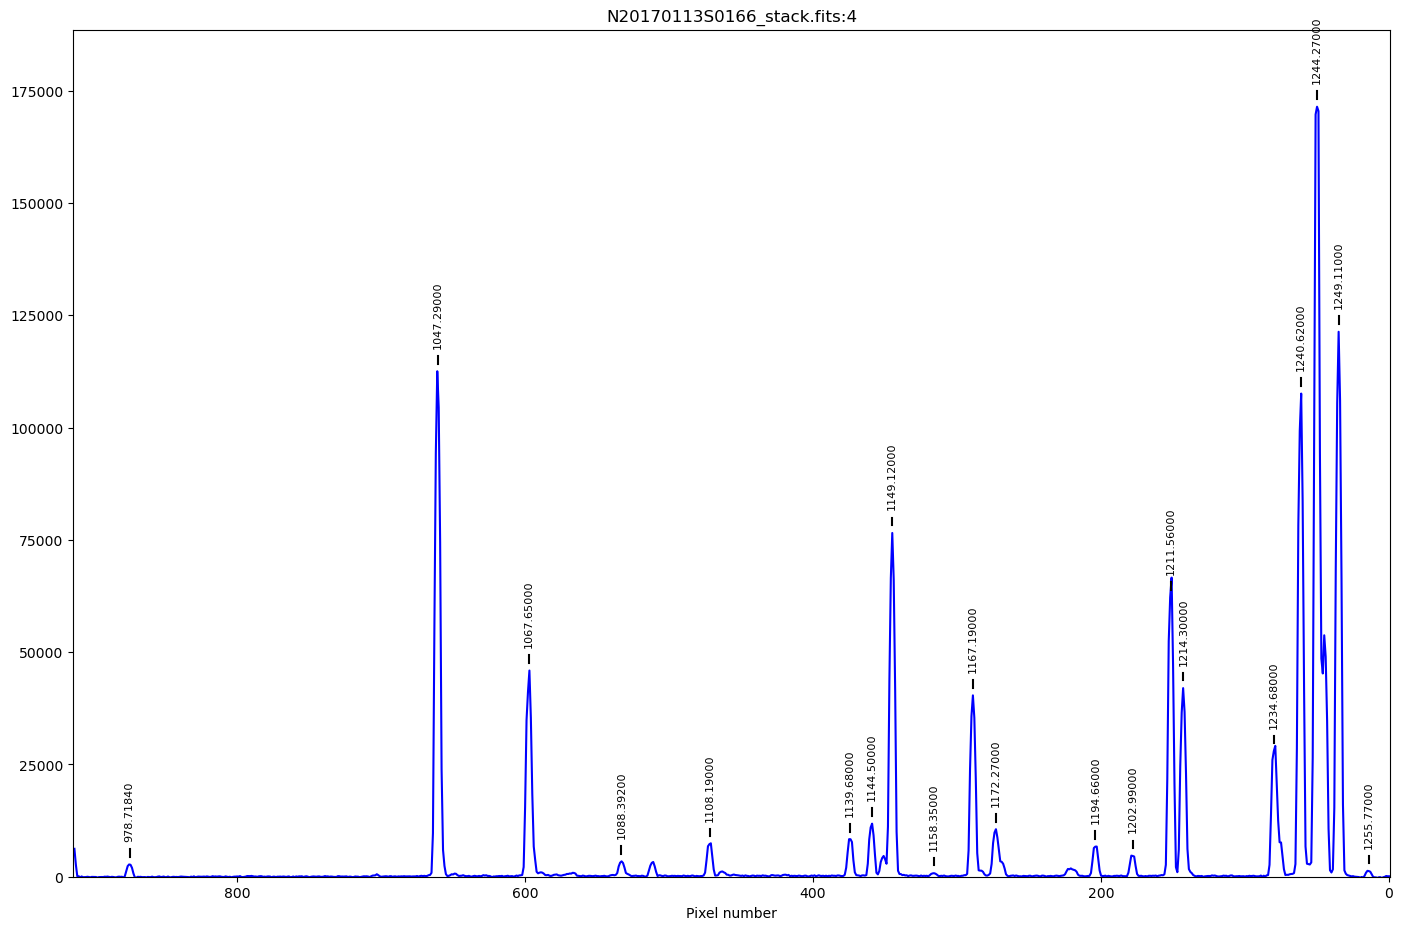

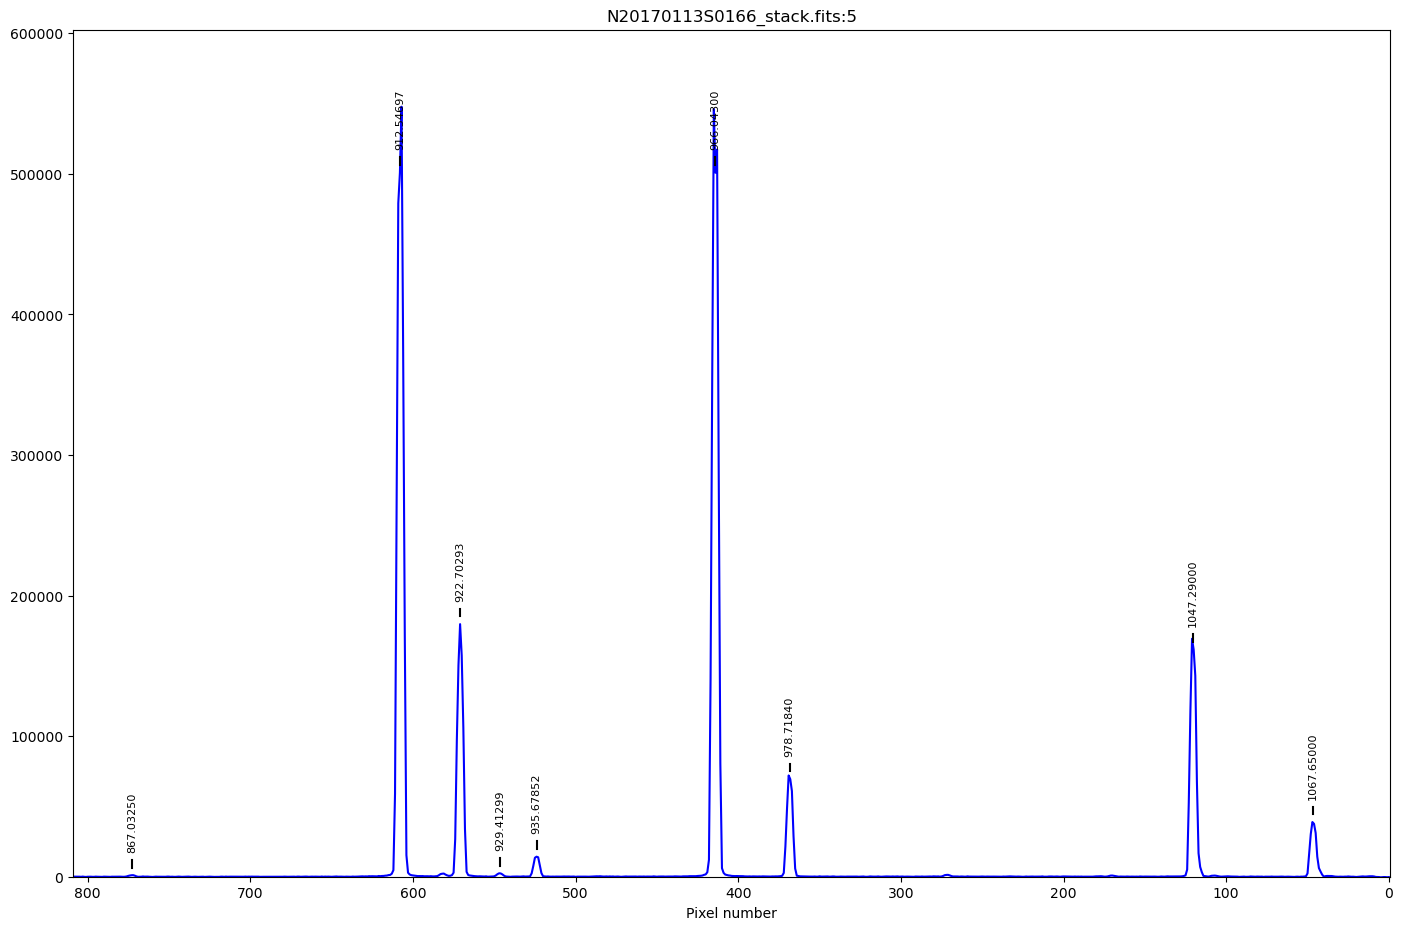

In [17]:
reduce_arcs = Reduce()
reduce_arcs.files.extend(arcs)
reduce_arcs.runr()

<a class="anchor" id="Telluric"></a>
# Telluric Standard

The telluric standard observed before the science observation is “hip 17030”. The spectral type of the star is A0V. To properly calculate and fit a telluric model to the star, we need to know its effective temperature. To properly scale the sensitivity function (to use the star as a spectrophotometric standard), we need to know the star’s magnitude. Those are inputs to the fitTelluric primitive.

To find these values, we can use the `star_info()` function that is defined below. If you pass the function a star name, it searches the SIMBAD database and returns the V-band flux. If you know your star's spectral type, provide it to the function, and it will return the star's effective temperature. If you do not know your star's spectral type, just pass the function the name of the star, and it will look for the spectral type before finding the temperature. 

For this example, we already know the star's spectral type. The default effective temperature of 9650 K is typical of an A0V star, which is the most common spectral type used as a telluric standard. Different sources give values between 9500 K and 9750 K, and, for example, Eric Mamajek’s list [“A Modern Mean Dwarf Stellar Color and Effective Temperature Sequence”](https://www.pas.rochester.edu/~emamajek/EEM_dwarf_UBVIJHK_colors_Teff.txt) quotes the effective temperature of an A0V star as 9700 K. The precise value has only a small effect on the derived sensitivity and even less effect on the telluric correction, so the temperature from any reliable source can be used. Using [Simbad](https://simbad.u-strasbg.fr/simbad/sim-fbasic), we find that the star has a magnitude of K=9.244.

Note that the data are recognized by Astrodata as normal GNIRS cross-dispersed science spectra. To calculate the telluric correction, we need to specify the telluric recipe, otherwise the default science reduction will be run.

The reduced telluric file will be named after the first telluric file, with the suffix _telluric.fits.

In [18]:
def star_info(star_name,spec_type=None):
    """Return V-band flux and effective temperature of a given star.
    
    Parameters
    ----------
    star_name : string
        Name of the star that will be searched for in the SIMBAD database.
    spec_type : string
        Spectral type of the star.
        If you do not know your star's spectral type, leave this parameter 
        blank, and if the spectral type is in SIMBAD's database, it will
        be returned and passed to the rest of the function. 
    
    Examples
    --------
    If you know the star's spectral type:
        v_flux, temp = star_info("hip 17030","A0V")

    If you do not know your star's spectral type:
        v_flux, temp = star_info("hip 17030")
    """
    #Load in the table with effective temperatures
    url = "https://www.pas.rochester.edu/~emamajek/EEM_dwarf_UBVIJHK_colors_Teff.txt"
    full_temp_df = pd.read_csv(url, skiprows=22, sep=r'\s+', header=0)
    temp_df = full_temp_df[:119]
    
    #The default table returned by SIMBAD does not contain V-band flux or 
    #spectral type, so we will start by telling SIMBAD to include these columns.
    #Identify V band flux value for star. 
    Simbad.add_votable_fields('V')

    if spec_type is None:
        Simbad.get_votable_fields().append('sp') 

        #Fetch the result table.
        result_table = Simbad.query_object(star_name)

        #Find the V-band flux
        flux = float(result_table['V'].data)
        flux_clean = round(flux,5)

        #Identify your star's spectral type.
        spec_type = result_table['sp_type'].data[0]

        #Find the effective temperature
        filt = temp_df['#SpT'] == spec_type
        temp = int(temp_df['Teff'][filt].iloc[0])
    
        return flux_clean, temp

    else:
        #Fetch the result table.
        result_table = Simbad.query_object(star_name)
    
        #Find the V-band flux
        flux = float(result_table['V'].data)
        flux_clean = round(flux,5)

        #Find the effective temperature
        filt = temp_df['#SpT'] == spec_type
        temp = int(temp_df['Teff'][filt].iloc[0])
    
        return flux_clean, temp

In [19]:
v_flux, temp = star_info("hip 17030","A0V")
print("V-band flux:",v_flux,"\nTemperature:",temp)

V-band flux: 9.36 
Temperature: 9700


In [20]:
reduce_telluric = Reduce()
reduce_telluric.files.extend(tellurics)
reduce_telluric.recipename = 'reduceTelluric'
reduce_telluric.uparms = dict([
            ('fitTelluric:bbtemp', temp),
            ('fitTelluric:magnitude', 'K=%f'%v_flux),            
            ])
reduce_telluric.runr()

All submitted files appear valid:
N20170113S0123.fits ... N20170113S0138.fits, 16 files submitted.
RECIPE: reduceTelluric
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0123_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0124_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0125_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0126_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0127_dataValidated.fits
         .
         PRIMITIVE: addMDF
         --------------

<a class="anchor" id="Science"></a>
# Science Observations

The science target is a supernova type II 54 days after explosion. The sequence is 5 ABBA dither pattern. DRAGONS will flatfield, wavelength calibrate, subtract the sky, stack the aligned spectra, extract the source, and finally remove telluric features and flux calibrate.

In the raw data, the red end is at the bottom and blue at the top. This will be reversed when the data is resampled and the distortion corrected and wavelength calibration are applied. With all the calibrations in the local calibration manager, one only needs to call Reduce on the science frames to get an extracted spectrum.

After running the following cell, a new file will be created called N20170113S0146_1D.fits.

In [21]:
reduce_science = Reduce()
reduce_science.files.extend(scitarget)
reduce_science.uparms = dict([
    ('extractSpectra:write_outputs', True),
    ('telluricCorrect:write_outputs', True)
])
reduce_science.runr()

All submitted files appear valid:
N20170113S0146.fits ... N20170113S0165.fits, 20 files submitted.
RECIPE: reduceScience
   PRIMITIVE: prepare
   ------------------
      PRIMITIVE: validateData
      -----------------------
      .
      PRIMITIVE: standardizeStructure
      -------------------------------
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0146_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0147_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0148_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0149_dataValidated.fits
         .
         PRIMITIVE: addMDF
         -----------------
         Added MDF table for N20170113S0150_dataValidated.fits
         .
         PRIMITIVE: addMDF
         ---------------

# Set up the plotting function

Now that all of the reduction steps are complete, let's plot the output. Below, we will plot four versions of the final spectrum. The first will show what the spectrum looks like without telluric correction, or flux calibration; the second will perform telluric correction, but not flux calibration; the third will display the results after performing both telluric correction and flux calibration; and the fourth will stitch all of the orders into a continuous spectrum. 

Since displaying the code will involve a lot of repetitive Matplotlib code, let's create a plotting function called `plotter` that takes a file name, opens the file, extracts the signal and wavelength information, and displays the plot. 

In [22]:
def plotter(file,adjust_y_lim=None):
    """Plot reduced spectra.
    
    Parameters
    ----------
    file : string
        Name of the file that will be plotted.
    adjust_y_lim : tuple (optional)
        A tuple containing the desired min and max value for the y-axis. 
    
    Examples
    --------
    If you want to use the default y-limits:
         plotter('N20170113S0146_ordersCombined.fits')

    If you want to adjust the y-limits:
        plotter('N20170113S0146_ordersCombined.fits',adjust_y_lim=(0,1e-17))
    """
    #Open the file with astrodata
    ad = astrodata.open(file)

    #Loop over all of the orders
    for j in range(0,len(ad)):
        data = ad[j].data
        wavelength = ad[j].wcs(np.arange(data.size)).astype(np.float32)
        units = ad[j].wcs.output_frame.unit[0]

        #Some observations contain noisy data that can be masked out. 
        #The mask information is stored as an extension.
        mask = ad[j].mask

        #Create a filter that will leave out the noisy data.
        is_good = (mask == 0)
        clean_wave = wavelength[is_good]
        clean_data = data[is_good]
    
        plt.xlabel(f'Wavelength ({units})')
        plt.ylabel(f'Signal ({ad[0].hdr["BUNIT"]})')
        
        plt.plot(clean_wave, clean_data, lw=0.5)

    if adjust_y_lim:
        plt.ylim(adjust_y_lim)
        
    plt.title(f'{file} - Aperture 1')
    plt.show()

<a class="anchor" id="Display_extracted"></a>
# Display the 1D extracted specturm

Because we set the option `extractSpectra:write_outputs` to True, we have access to the 1D extracted spectrum before telluric correction or flux calibration. You can plot all the orders of the extracted spectrum on a common plot using dgsplot as shown below. 

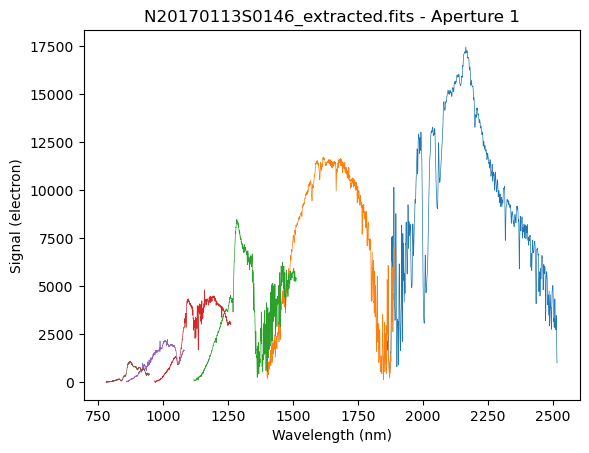

In [23]:
plotter('N20170113S0146_extracted.fits')

<a class="anchor" id="Display_telluricCorrected"></a>
# Display the telluric corrected spectrum

Now, let's inspect the spectrum after telluric correction, but before flux calibration. 

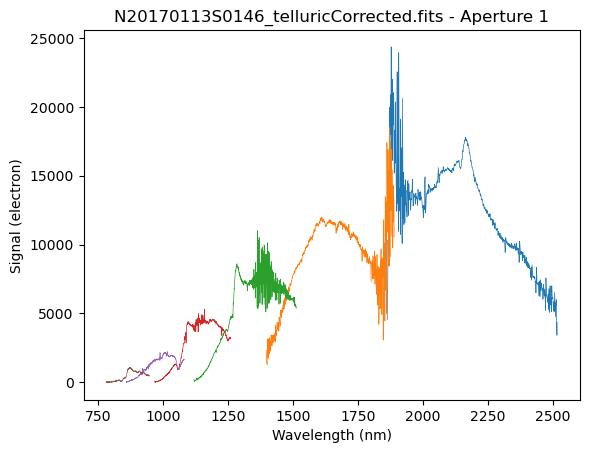

In [24]:
plotter('N20170113S0146_telluricCorrected.fits')

<a class="anchor" id="Display_final"></a>
# Display the final spectrum

Now, we can use dgsplot to display the final spectrum, which has been corrected for telluric features and flux calibrated. 

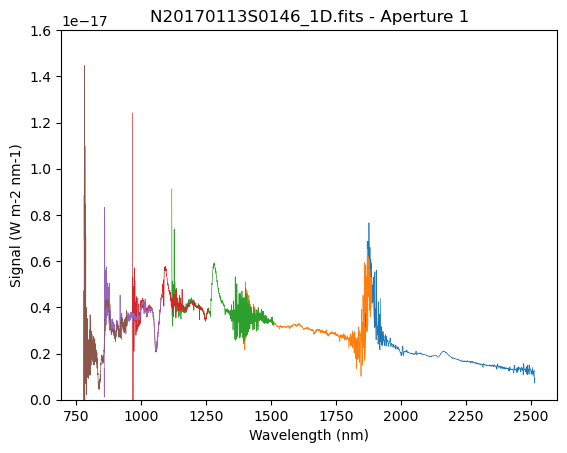

In [25]:
plotter(reduce_science.output_filenames[0],adjust_y_lim=(0,1.6e-17))

<a class="anchor" id="Combine_orders"></a>
# Combine Orders

When displaying the final spectrum, the orders remain separated. If you need to stitch the orders and stack the common wavelength ranges, you can use the `combineOrders` primative as demonstrated below. 

In [26]:
reduce_combine = Reduce()
reduce_combine.recipename = 'combineOrders'
reduce_combine.files.extend([reduce_science.output_filenames[0]])
reduce_combine.runr()

All submitted files appear valid:
N20170113S0146_1D.fits
WARNING - No recipe can be found in gnirs recipe libs.
WARNING - Searching primitives ...
Found 'combineOrders' as a primitive.
RECIPE: combineOrders
   PRIMITIVE: combineOrders
   ------------------------
      PRIMITIVE: resampleToCommonFrame
      --------------------------------
      Resampling and linearizing N20170113S0146order3_1D.fits extension 1: w1=700.236 w2=2516.903 dw=0.240 npix=7560
      Array maps to [4836:7559]
      Resampling and linearizing N20170113S0146order4_1D.fits extension 1: w1=700.236 w2=2516.903 dw=0.240 npix=7560
      Array maps to [2901:4948]
      Resampling and linearizing N20170113S0146order5_1D.fits extension 1: w1=700.236 w2=2516.903 dw=0.240 npix=7560
      Array maps to [1741:3378]
      Resampling and linearizing N20170113S0146order6_1D.fits extension 1: w1=700.236 w2=2516.903 dw=0.240 npix=7560
      Array maps to [967:2331]
      Resampling and linearizing N20170113S0146order7_1D.fits ex

<a class="anchor" id="Display_Combine_orders"></a>
# Display Combined Orders

Now that we have combined all the orders, let's see what the spectrum looks like combined. 

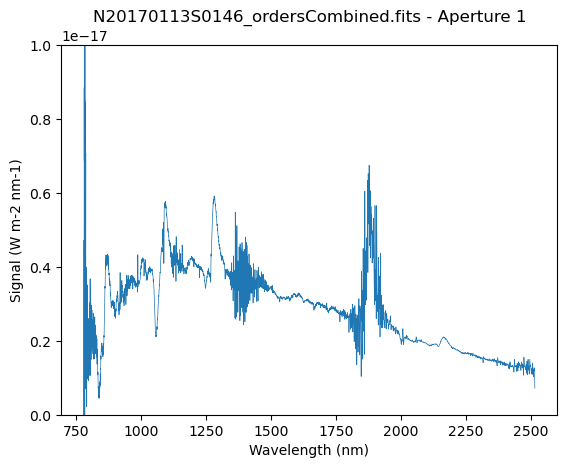

In [27]:
plotter('N20170113S0146_ordersCombined.fits',adjust_y_lim=(0,1e-17))

<a class="anchor" id="Clean-up"></a>
# Optional: remove duplicate calibrations and remove raw data (uncomment lines before running)

In [29]:
#clean_up(save_reduced=1)